# <center> Avance EDA </center>


In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns




### El equipo de marketing nos dió una base de datos para analizar y determinar cual es la mejor estrategia para mejorar las ventas de un restaurant objetivo

---------------------------------------------------------------------------------------------------------------------------------------------------------------------

##### Objetivo del Análisis: Identificar el perfil de cliente que genera mayores ingresos para el restaurante. Para esto, analizaremos la variable 'promedio_gasto_comida' cruzándola con datos demográficos, geográficos y poder adquisitivo, con el fin de definir una segmentación de marketing efectiva. En otras palabras encontraremos el perfil de el "mejor cliente", el que más consume, para que el equipo de marketing afine su segmentación actual.

...........................................................................................................................................................................................................

#### <span style="color:yellow">Lectura del archivo y tipo de datos</span>

In [2]:
#Lectura de archivo 

archivo_restaurantes = 'base_datos_restaurantes_USA_v2.csv'
df_restaurantes = pd.read_csv(archivo_restaurantes, dtype={"telefono_contacto": str, "id_persona": str})


display(df_restaurantes.head())
print(df_restaurantes.dtypes)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


id_persona                    object
nombre                        object
apellido                      object
edad                         float64
genero                        object
ciudad_residencia             object
estrato_socioeconomico        object
frecuencia_visita              int64
promedio_gasto_comida        float64
ocio                          object
consume_licor                 object
preferencias_alimenticias     object
membresia_premium             object
telefono_contacto             object
correo_electronico            object
tipo_de_pago_mas_usado        object
ingresos_mensuales             int64
dtype: object


#### <span style="color:yellow">Visualización de cantidad de personas por ciudad</span>

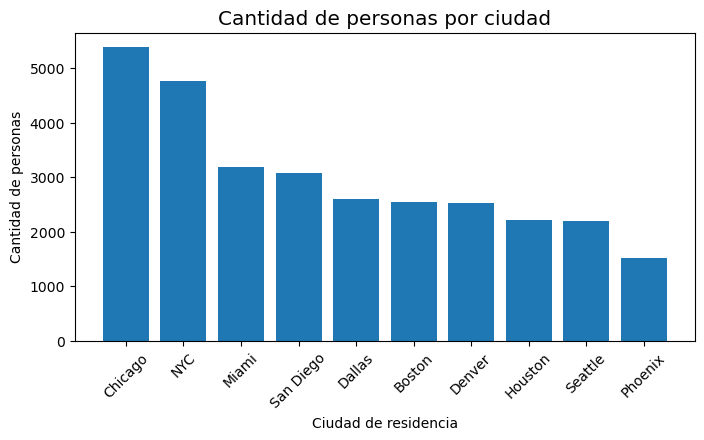

In [3]:
#Matploit gráfico de barras verticales
cant_personas= df_restaurantes["ciudad_residencia"].value_counts()

fix, ax = plt.subplots(figsize=(8,4))
ax.bar( cant_personas.index, cant_personas.values)


plt.style.use("ggplot")

ax.set_title("Cantidad de personas por ciudad")
ax.set_xlabel("Ciudad de residencia")
ax.set_ylabel("Cantidad de personas")
plt.xticks(rotation=45)


plt.show()

#### <span style="color:yellow">¿Cómo se distribuyen las personas según su estrato socioeconómico?</span>

In [4]:
listado_estrato = df_restaurantes["estrato_socioeconomico"].value_counts()

tabla_estratos = listado_estrato.reset_index()
tabla_estratos.columns = ['Estrato socioeconómico', 'Cantidad de Personas']

print("Distribución por Estrato Socioeconómico:")
display(tabla_estratos.style.hide(axis='index'))



Distribución por Estrato Socioeconómico:


Estrato socioeconómico,Cantidad de Personas
Medio,9325
Alto,9038
Bajo,6161
Muy Alto,5476


#### <span style="color:yellow">Ciudades que más dinero se gasta en promedio, por mes</span>

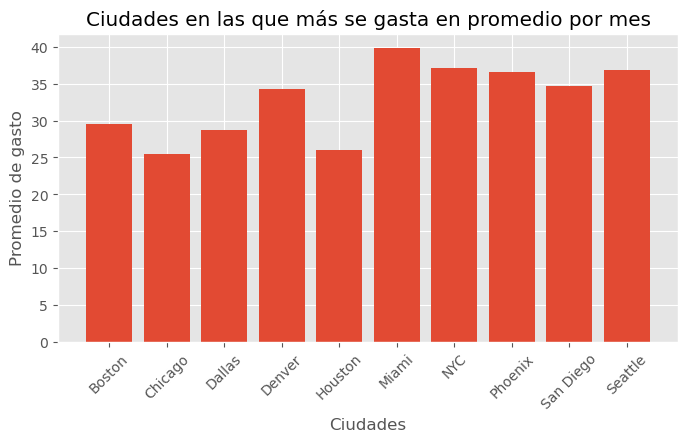

In [5]:
#Matploit gráfico de barras verticales
gasto_ciudad= df_restaurantes.groupby("ciudad_residencia")["promedio_gasto_comida"].mean()

fig, ax = plt.subplots(figsize=(8,4))
ax.bar( gasto_ciudad.index, gasto_ciudad.values)


plt.style.use("ggplot")

ax.set_title("Ciudades en las que más se gasta en promedio por mes")
ax.set_xlabel("Ciudades")
ax.set_ylabel("Promedio de gasto")
plt.xticks(rotation=45)


plt.show()

#### <span style="color:yellow">Relación entre la frecuencia de visita y el gasto económico según el estrato socioeconómico</span>

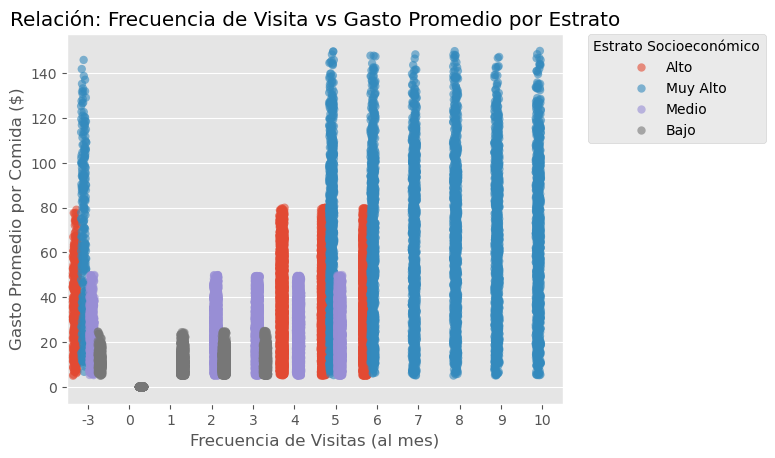

In [6]:
#Seaborn gráfico de dispersión

plt.Figure(figsize=(14,8))

sns.stripplot(data=df_restaurantes,
                 x="frecuencia_visita",
                  y="promedio_gasto_comida",
                  hue="estrato_socioeconomico",
                  jitter=0.25, 
                    size=6, 
                    alpha=0.6, 
                    dodge=True)

plt.title("Relación: Frecuencia de Visita vs Gasto Promedio por Estrato")
plt.xlabel("Frecuencia de Visitas (al mes)")
plt.ylabel("Gasto Promedio por Comida ($)")
plt.legend(title="Estrato Socioeconómico", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


plt.show()

#### <span style="color:yellow">Gasto promedio gasto mensual vs ingresos mensuales</span>

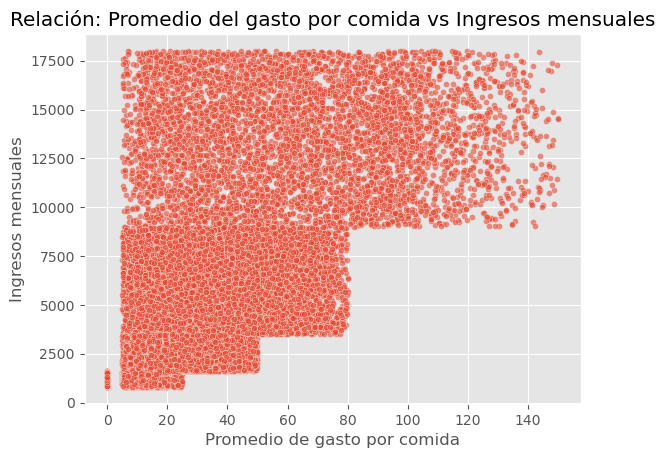

In [7]:
#Seaborn gráfico de dispersión

plt.Figure(figsize=(10,4))


sns.scatterplot(data=df_restaurantes,
                 x="promedio_gasto_comida",
                  y="ingresos_mensuales",
                  alpha=0.6, 
                  s=20
                 )

plt.title("Relación: Promedio del gasto por comida vs Ingresos mensuales")
plt.xlabel("Promedio de gasto por comida")
plt.ylabel("Ingresos mensuales")



plt.show()

#### <span style="color:yellow">Preferencias alimenticias por ciudad</span>

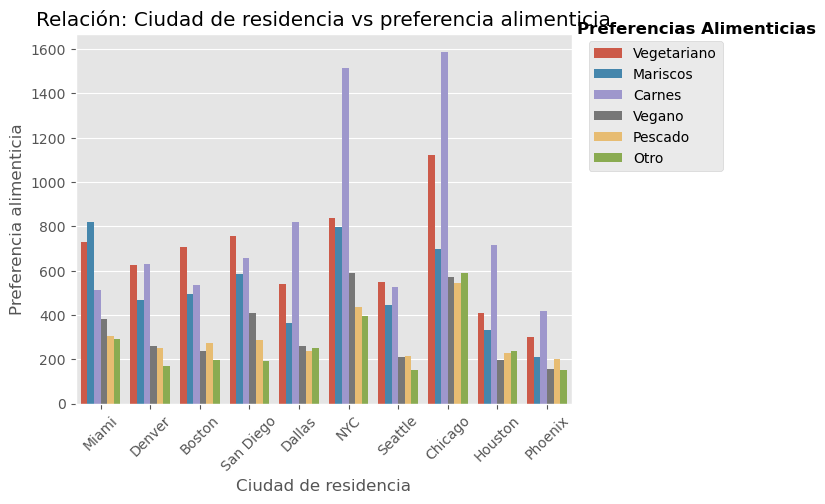

In [8]:
#Seaborn gráfico de barras

plt.Figure(figsize=(14,8))

sns.countplot(data=df_restaurantes,
                 x="ciudad_residencia",
                  hue="preferencias_alimenticias"
                  )

plt.title("Relación: Ciudad de residencia vs preferencia alimenticia")
plt.xlabel("Ciudad de residencia")
plt.ylabel("Preferencia alimenticia")
plt.xticks(rotation=45)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.text(1.01, 1, "Preferencias Alimenticias", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         fontweight='bold', 
         ha='left')

plt.show()

#### <span style="color:yellow">Clientes de mayor gasto</span>

C:\Users\Cristian\AppData\Local\Temp\ipykernel_20832\3701573957.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clientes_vip['gasto_mensual_total'] = clientes_vip['promedio_gasto_comida'] * clientes_vip['frecuencia_visita']


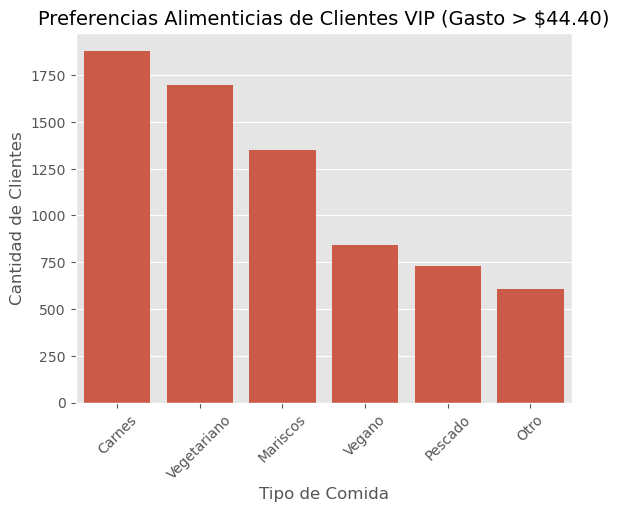

In [9]:
#Clientes de mayor gasto
clientes_vip = df_restaurantes[df_restaurantes['promedio_gasto_comida'] > 80]

#Preferencias alimenticias de los clientes vip
preferencias_alim = clientes_vip["preferencias_alimenticias"].value_counts

clientes_vip['gasto_mensual_total'] = clientes_vip['promedio_gasto_comida'] * clientes_vip['frecuencia_visita']

#Promedio de ese gasto mensual
promedio_mensual_vip = clientes_vip['gasto_mensual_total'].mean()

q3_gasto = df_restaurantes['promedio_gasto_comida'].quantile(0.75)
clientes_vip = df_restaurantes[df_restaurantes['promedio_gasto_comida'] >= q3_gasto].copy()

#Seaborn gráfico de barras
plt.Figure(figsize=(14,8))

sns.countplot(data=clientes_vip,
                 x="preferencias_alimenticias",
                  order=clientes_vip['preferencias_alimenticias'].value_counts().index)


plt.title(f"Preferencias Alimenticias de Clientes VIP (Gasto > ${q3_gasto:.2f})", fontsize=14)
plt.xlabel("Tipo de Comida")
plt.ylabel("Cantidad de Clientes")
plt.xticks(rotation=45)


plt.show()

#### <span style="color:yellow">Ciudades en las que más membresías se pagan</span>

La ciudad con mayor cantidad de membresías Premium es Chicago con 2215 socios.


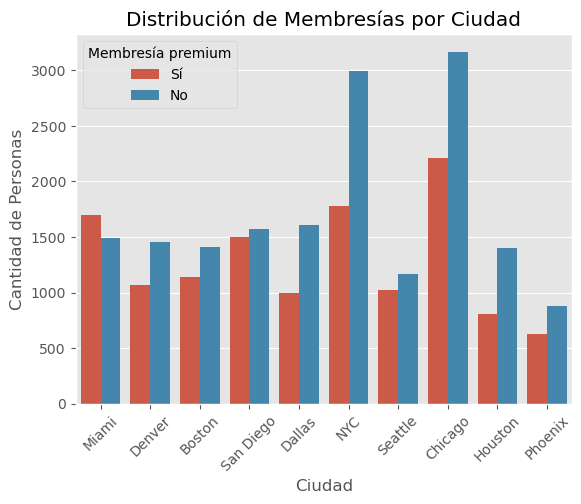

In [10]:
#Seaborn gráfico de barras verticales


sns.countplot(data=df_restaurantes, 
              x="ciudad_residencia", 
              hue="membresia_premium", 
             )

plt.title("Distribución de Membresías por Ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de Personas")
plt.xticks(rotation=45)
plt.legend(title="Membresía premium")



solo_premium = df_restaurantes[df_restaurantes["membresia_premium"] == "Sí"]

conteo_premium = solo_premium['ciudad_residencia'].value_counts()

ciudad_top = conteo_premium.idxmax()
cantidad_top = conteo_premium.max()

print(f"La ciudad con mayor cantidad de membresías Premium es {ciudad_top} con {cantidad_top} socios.")

plt.show()


#### <span style="color:yellow">Consumo de alcohol y edad de los clientes</span>

C:\Users\Cristian\AppData\Local\Temp\ipykernel_20832\1605929040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtro_edad, x="consume_licor", y="edad", palette="Set2")


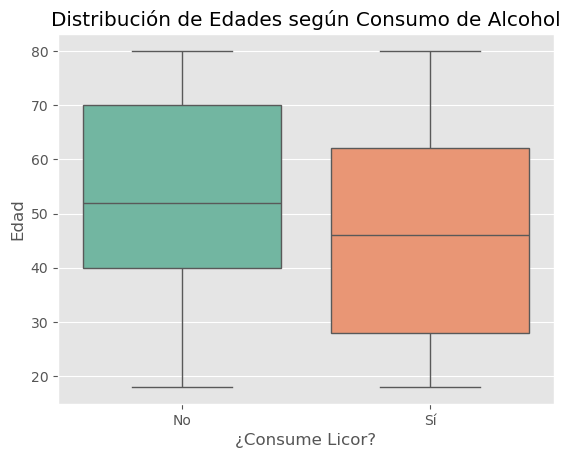

In [11]:
#Seaborn gráfico de barras verticales
filtro_edad = df_restaurantes[df_restaurantes["edad"].between(18,100)]

sns.boxplot(data=filtro_edad, x="consume_licor", y="edad", palette="Set2")

plt.style.use("ggplot")

plt.title("Distribución de Edades según Consumo de Alcohol")
plt.xlabel("¿Consume Licor?")
plt.ylabel("Edad")
plt.show()

#### <span style="color:yellow">Valores nulos</span>

In [12]:
#Cantidad totales de valores nulos 

print("Valores nulos por columna:")
print(df_restaurantes.isnull().sum())

Valores nulos por columna:
id_persona                       0
nombre                           0
apellido                         0
edad                           101
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64


#### <span style="color:yellow">Porcentaje de datos nulos</span>

Se calcula la cantidad de datos totales de la tabla y el porcentaje de datos nulos, para tomar mejores decisiones

In [13]:
#Tamaño total de datos de la tabla y porcentaje de datos nulos

print(f"Tamaño total de la tabla: {df_restaurantes.shape}")
porcentaje_de_nulos= ((df_restaurantes.isnull().sum()) / len(df_restaurantes)) *100
print("\n Porcentaje de nulos por columna:")
print(porcentaje_de_nulos)

Tamaño total de la tabla: (30000, 17)

 Porcentaje de nulos por columna:
id_persona                    0.000000
nombre                        0.000000
apellido                      0.000000
edad                          0.336667
genero                        0.000000
ciudad_residencia             0.000000
estrato_socioeconomico        0.000000
frecuencia_visita             0.000000
promedio_gasto_comida         0.483333
ocio                          0.000000
consume_licor                 0.000000
preferencias_alimenticias     4.676667
membresia_premium             0.000000
telefono_contacto            50.553333
correo_electronico           50.240000
tipo_de_pago_mas_usado        0.000000
ingresos_mensuales            0.000000
dtype: float64


#### <span style="color:yellow">Limpieza de datos</span>

Se decide borrar las columnas teléfono y contacto ya que no es relevante para el análisis y la mitad de los datos son nulos


In [14]:
#Borrado de columna teléfono y contacto

df_restaurantes.drop(columns=["telefono_contacto", "correo_electronico"], inplace=True)

Se realiza limpieza de datos nulos de la columna "Preferencias alimenticias"

In [15]:
#Limpieza de columna preferencias alimenticias

df_restaurantes["preferencias_alimenticias"] = df_restaurantes["preferencias_alimenticias"].fillna("No específica")

Se promedian las edades para los datos nulos

In [16]:
#Limpieza de columna edad en base al promedio

df_restaurantes["edad"] = df_restaurantes["edad"].fillna(df_restaurantes["edad"].median())

Se promedia el "promedio gasto por comida" para los datos nulos

In [17]:
#Limpieza de columna "promedio gasto comida" en base al promedio

df_restaurantes["promedio_gasto_comida"] = df_restaurantes["promedio_gasto_comida"].fillna(df_restaurantes["promedio_gasto_comida"].median())

Se verifica que no hayan quedados datos nulos

In [18]:
#Verificación de nulos restantes

print("Nulos restantes:")
print(df_restaurantes.isnull().sum())

Nulos restantes:
id_persona                   0
nombre                       0
apellido                     0
edad                         0
genero                       0
ciudad_residencia            0
estrato_socioeconomico       0
frecuencia_visita            0
promedio_gasto_comida        0
ocio                         0
consume_licor                0
preferencias_alimenticias    0
membresia_premium            0
tipo_de_pago_mas_usado       0
ingresos_mensuales           0
dtype: int64


#### <span style="color:yellow">Datos duplicados</span>

Se verifica si existen datos duplicados

In [19]:
#Verificación de cantidad de datos duplicados

print(f"Cantidad de datos duplicados: {df_restaurantes.duplicated().sum()}")

Cantidad de datos duplicados: 0


#### <span style="color:yellow">Verificación de errores en edad y frecuencia de visitas</span>

Se verifican estas dos áreas porque son las que se analizarán posteriormente

In [20]:
#Verificación de errores de edad y errores en la frecuencia de visitas

errores_edad = df_restaurantes[(df_restaurantes["edad"] < 0) | (df_restaurantes["edad"] > 110)]

error_frecuencia_visitas = df_restaurantes[df_restaurantes["frecuencia_visita"] <= 0 ]

error_frecuencia_visitas_máximos= df_restaurantes["frecuencia_visita"].max()

error_frecuencia_visitas_minimo = df_restaurantes["frecuencia_visita"].min()

print(f"Errores de edad encontrados: {len(errores_edad)}")
print(f"Errores de visitas encontrados: {len(error_frecuencia_visitas)}")
print(f"Cantidad maximas de visitas: {error_frecuencia_visitas_máximos}")
print(f"Cantidad mínima de visitas: {error_frecuencia_visitas_minimo}")





Errores de edad encontrados: 207
Errores de visitas encontrados: 3010
Cantidad maximas de visitas: 10
Cantidad mínima de visitas: -3


Utilizamos la mediana para reemplazar los datos errones en la frecuencia de visitas

In [21]:
mediana_frecuencia = df_restaurantes[df_restaurantes["frecuencia_visita"] > 0]["frecuencia_visita"].median()

print(f"La mediana de visitas es: {mediana_frecuencia}")


df_restaurantes.loc[df_restaurantes["frecuencia_visita"] <= 0, "frecuencia_visita"] = mediana_frecuencia


conteo_errores = (df_restaurantes["frecuencia_visita"] <= 0).sum()
print(f"Errores después de la limpieza: {conteo_errores}")

La mediana de visitas es: 4.0
Errores después de la limpieza: 0


Se reemplazan los errores de la edad por la mediana

In [22]:
#Remplazar los errores de edad, por la mediana

edad_mediana = df_restaurantes["edad"].median()

df_restaurantes.loc[(df_restaurantes["edad"] < 0) | (df_restaurantes["edad"] > 100), "edad"] = edad_mediana

print(f"Nueva edad máxima: {df_restaurantes["edad"].max()}")
print(f"Nueva edad mínima: {df_restaurantes["edad"].min()}")

Nueva edad máxima: 80.0
Nueva edad mínima: 18.0


#### <span style="color:cyan">A continuación graficaremos nuestro objetivo: Para lograr una buena segmentación vamos a graficar en base al promedio de gasto por comida versus y de manera individual, edad, género, preferencias alimenticias, estracto económico y ciudad; para luego obtener la mejor información de cada uno de ellos, es decir, los mayores consumidores de cada seccción.</span>

## <span style="color:blue">Gráficos</span>

Gasto promedio por rango etario

Publico objetivo: El rango 36-45 
 (Adultos) es el que más gasta ($33.07)


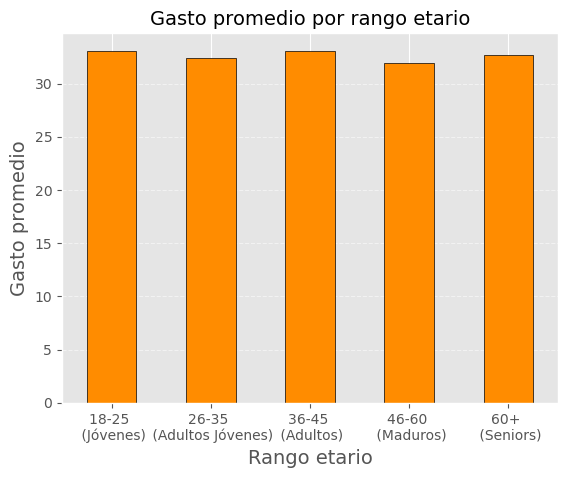

In [23]:
#Gráfico sobre los que más gastan según la edad

franja_etaria = [17, 25, 35, 45, 60, 100]
etiquetas = ["18-25 \n (Jóvenes)","26-35 \n (Adultos Jóvenes)","36-45 \n (Adultos)","46-60 \n (Maduros)","60+ \n (Seniors)"]

df_restaurantes["rango_etario"] = pd.cut(df_restaurantes["edad"], bins=franja_etaria, labels=etiquetas)


promedios_por_rango = df_restaurantes.groupby("rango_etario", observed=False)["promedio_gasto_comida"].mean()

rango_ganador = promedios_por_rango.idxmax()
valor_maximo= promedios_por_rango.max()

print(f"Publico objetivo: El rango {rango_ganador} es el que más gasta (${valor_maximo:.2f})")

plt.Figure(figsize=(10,6))
promedios_por_rango.plot(kind="bar", color="darkorange", edgecolor= "black")

plt.title("Gasto promedio por rango etario", fontsize=14)
plt.xlabel("Rango etario", fontsize= 14)
plt.ylabel("Gasto promedio", fontsize= 14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Gasto promedio por género

El género con mayor consumo promedio es: Femenino
Gasto promedio de este grupo: $32.74


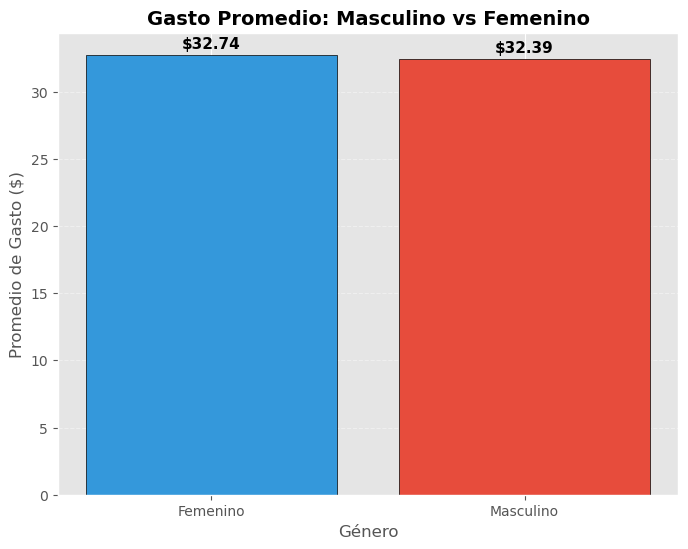

In [24]:
#Gráfico sobre los que más gastan según el genero

gasto_genero = df_restaurantes.groupby("genero", observed=False)["promedio_gasto_comida"].mean()

gasto_genero = gasto_genero.loc[gasto_genero.index.isin(['Masculino', 'Femenino'])]


plt.figure(figsize=(8, 6))

plt.bar(gasto_genero.index, gasto_genero.values, color=['#3498db', '#e74c3c'], edgecolor='black')

plt.title("Gasto Promedio: Masculino vs Femenino", fontsize=14, fontweight='bold')
plt.xlabel("Género", fontsize=12)
plt.ylabel("Promedio de Gasto ($)", fontsize=12)

for i, v in enumerate(gasto_genero.values):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center', fontweight='bold', fontsize=11)


genero_ganador = gasto_genero.idxmax()
valor_maximo_gen = gasto_genero.max()



print(f"El género con mayor consumo promedio es: {genero_ganador}")
print(f"Gasto promedio de este grupo: ${valor_maximo_gen:.2f}")



plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Gasto promedio por estracto económico

ANÁLISIS ESTRACTO ECONÓMICO
 El estracto enconómico que más consumo es: Muy Alto
Estracto que más consume: $64.26


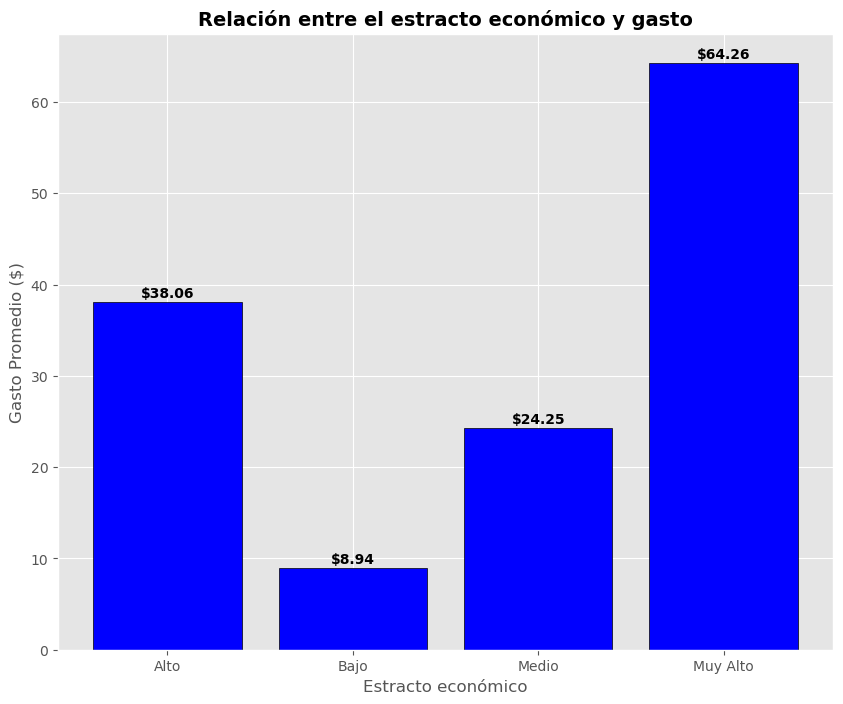

In [25]:
#Gráfico sobre los que más gastan según la el estracto económico

top_estracto_economico = df_restaurantes.groupby("estrato_socioeconomico", observed=False)["promedio_gasto_comida"].mean().sort_index()

estracto_ganador = top_estracto_economico.idxmax()
valor_max_estracto = top_estracto_economico.max()

print(f"ANÁLISIS ESTRACTO ECONÓMICO")
print(f" El estracto enconómico que más consumo es: {estracto_ganador}")
print(f"Estracto que más consume: ${valor_max_estracto:.2f}")

plt.figure(figsize=(10, 8))

plt.bar(top_estracto_economico.index.astype(str), top_estracto_economico.values, color="blue", edgecolor='black')

plt.title("Relación entre el estracto económico y gasto", fontsize=14, fontweight='bold')
plt.xlabel("Estracto económico")
plt.ylabel("Gasto Promedio ($)")


for i, v in enumerate(top_estracto_economico.values):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center', fontweight='bold')

plt.show()

Gasto promedio por ciudad de residencia

ANÁLISIS GEOGRÁFICO DE VENTAS
La ciudad con el ticket promedio más alto es: Miami
Promedio de gasto en esa ciudad: $39.75


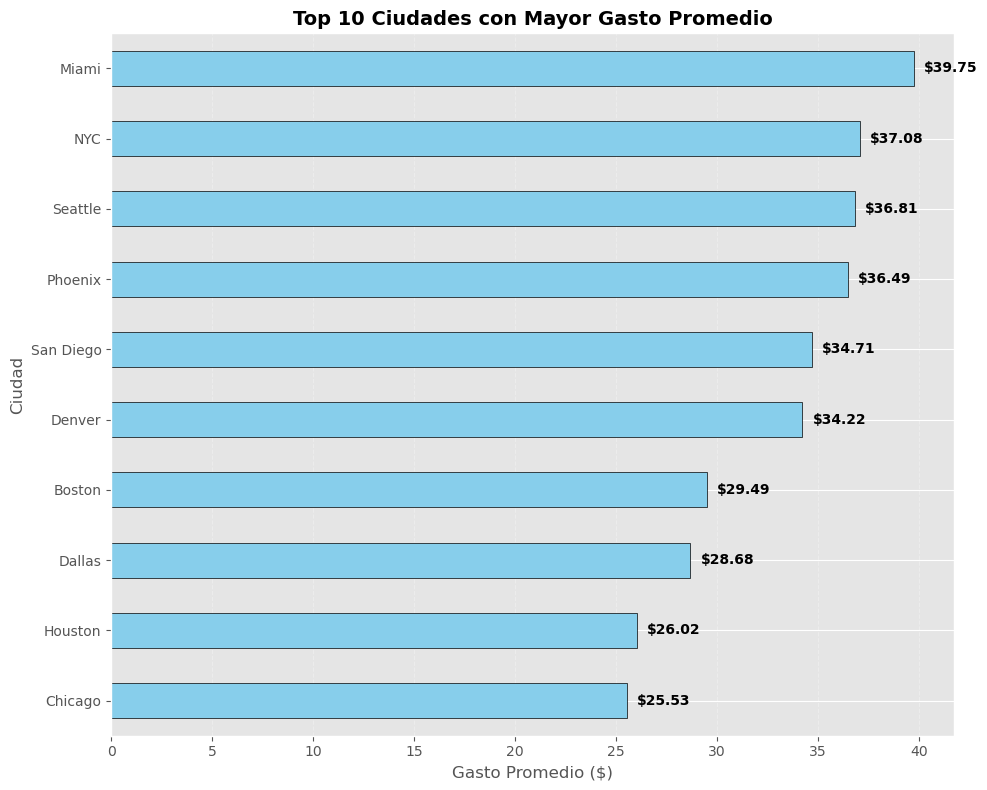

In [26]:
#Gráfico sobre los que más gastan según la ciudad de residencia

top_ciudades = df_restaurantes.groupby("ciudad_residencia")["promedio_gasto_comida"].mean().sort_values(ascending=False).head(10)

ciudad_ganadora = top_ciudades.idxmax()
valor_max_ciudad = top_ciudades.max()

print(f"ANÁLISIS GEOGRÁFICO DE VENTAS")
print(f"La ciudad con el ticket promedio más alto es: {ciudad_ganadora}")
print(f"Promedio de gasto en esa ciudad: ${valor_max_ciudad:.2f}")

plt.figure(figsize=(10, 8))
top_ciudades.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title("Top 10 Ciudades con Mayor Gasto Promedio", fontsize=14, fontweight='bold')
plt.xlabel("Gasto Promedio ($)")
plt.ylabel("Ciudad")


plt.gca().invert_yaxis() 

for i, v in enumerate(top_ciudades):
    plt.text(v + 0.5, i, f"${v:.2f}", va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### <span style="color:yellow">Filtrado por la ciudad de Miami

In [27]:
# Filtrado por la ciudad de Miami
# Miami fue elegida por tener el mayor gasto promedio según el análisis anterior

df_miami = df_restaurantes[df_restaurantes["ciudad_residencia"] == "Miami"].copy()

print(f"Datos filtrados para Miami: {len(df_miami):,} registros")
display(df_miami.head())

Datos filtrados para Miami: 3,186 registros


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales,rango_etario
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,Efectivo,6425,26-35 \n (Adultos Jóvenes)
16,6139475525,Andrew,Soto,18.0,Masculino,Miami,Muy Alto,9,26.60,Sí,Sí,Vegetariano,Sí,App,13452,18-25 \n (Jóvenes)
37,5358661821,Elizabeth,Brown,79.0,Femenino,Miami,Muy Alto,6,28.43,No,No,Mariscos,Sí,Efectivo,14072,60+ \n (Seniors)
45,8593345998,Robert,Wilson,76.0,Masculino,Miami,Alto,5,43.00,Sí,No,Mariscos,Sí,App,6528,60+ \n (Seniors)
47,6170452916,Bruce,Young,55.0,Masculino,Miami,Muy Alto,5,119.85,Sí,No,Carnes,Sí,Efectivo,15844,46-60 \n (Maduros)


#### <span style="color:yellow">¿Cuáles son las personas que más consumen en la ciudad de Miami? 

In [28]:
q3_gasto = df_miami["promedio_gasto_comida"].quantile(0.75)

df_miami_vip = df_miami[df_miami["promedio_gasto_comida"] >= q3_gasto].copy()

print(f"Umbral VIP (Q3): ${q3_gasto:.2f}")
print(f"Clientes VIP en Miami: {len(df_miami_vip):,}")

Umbral VIP (Q3): $53.91
Clientes VIP en Miami: 797


#### <span style="color:yellow">Preferencias alimenticias de los clientes vip de Miami

<Axes: xlabel='preferencias_alimenticias', ylabel='count'>

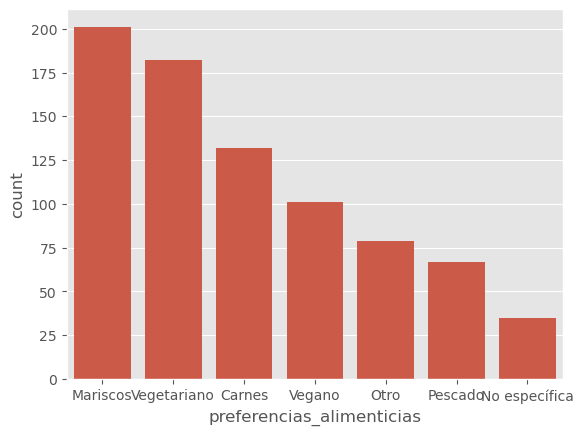

In [29]:
sns.countplot(data=df_miami_vip,
              x="preferencias_alimenticias",
              order=df_miami_vip["preferencias_alimenticias"].value_counts().index)

#### <span style="color:yellow">Clientes vip: Cantidad de personas según la edad 

In [30]:
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']

df_miami_vip['rango_etario'] = pd.cut(df_miami_vip['edad'], bins=bins, labels=labels)

print(df_miami_vip['rango_etario'].value_counts().sort_index())

rango_etario
18-25     86
26-35    136
36-45    122
46-60    184
60+      258
Name: count, dtype: int64


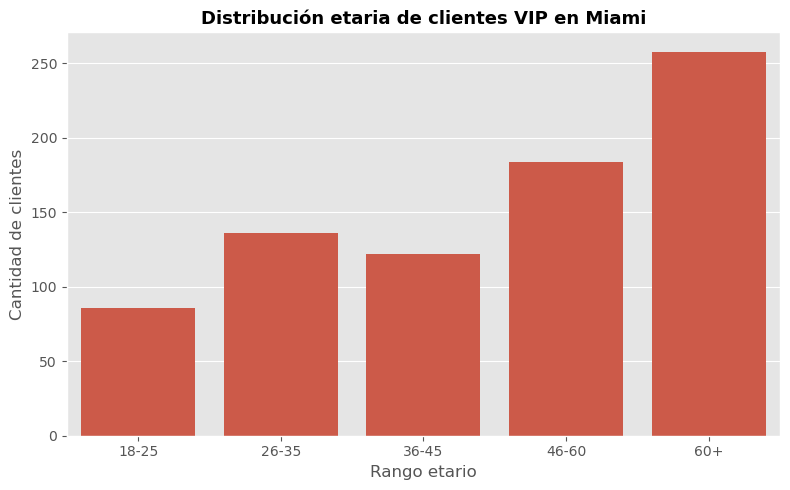

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

orden = ['18-25', '26-35', '36-45', '46-60', '60+']
sns.countplot(data=df_miami_vip, x='rango_etario', order=orden, ax=ax)

ax.set_title('Distribución etaria de clientes VIP en Miami', fontsize=13, fontweight='bold')
ax.set_xlabel('Rango etario')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

#### <span style="color:yellow">Clientes vip: ¿Quines gastan más hombres o mujeres?

In [32]:
gasto_genero = df_miami_vip.groupby('genero')['promedio_gasto_comida'].mean().round(2)

print("Gasto promedio por género (clientes VIP Miami):")
display(gasto_genero)

Gasto promedio por género (clientes VIP Miami):


genero
Femenino     81.03
Masculino    79.59
Name: promedio_gasto_comida, dtype: float64

In [33]:
rango_top = df_miami_vip['rango_etario'].value_counts().idxmax()
porcentaje_60_mas = (df_miami_vip[df_miami_vip['rango_etario'] == '60+'].shape[0] / len(df_miami_vip) * 100)
porcentaje_46_mas = (df_miami_vip[df_miami_vip['edad'] >= 46].shape[0] / len(df_miami_vip) * 100)

print("=" * 45)
print("     PERFIL DEL CLIENTE OBJETIVO")
print("=" * 45)
print(f"  Ciudad: Miami")
print(f"  Gasto mínimo (Q3): ${q3_gasto:.2f}")
print(f"  Gasto promedio del grupo: ${df_miami_vip['promedio_gasto_comida'].mean():.2f}")
print(f"  Estrato más frecuente: {df_miami_vip['estrato_socioeconomico'].mode()[0]}")
print(f"  Rango etario principal: 46 años en adelante")
print(f"  Representan el: {porcentaje_46_mas:.1f}% de los clientes VIP")
print(f"  Grupo de mayor gasto: 60+ ({porcentaje_60_mas:.1f}% del segmento)")
print(f"  Ambos sexos consumen por igual")

print("=" * 45)

     PERFIL DEL CLIENTE OBJETIVO
  Ciudad: Miami
  Gasto mínimo (Q3): $53.91
  Gasto promedio del grupo: $80.31
  Estrato más frecuente: Muy Alto
  Rango etario principal: 46 años en adelante
  Representan el: 55.5% de los clientes VIP
  Grupo de mayor gasto: 60+ (32.4% del segmento)
  Ambos sexos consumen por igual


#### Conclusiones:
 El equipo de marketing debería enfocar su segmentación a personas de ambos sexos, de entre 46 años en adelantes de la ciudad de Miami y con el poder adquisitivo muy alto, para obtener los mejores resultados en sus campañas publicitarias, ya que son éstos los clientes que mayor consumo generan en el restaurante

#### <span style="color:blue">Integración</span>

In [34]:
#Creamos una copia de todos los resultados obtenidos en un csv nuevo para luego hacer la integreación con la API
columnas_exportar = [
    'id_persona', 'nombre', 'apellido', 'edad', 'genero',
    'ciudad_residencia', 'estrato_socioeconomico', 'frecuencia_visita',
    'promedio_gasto_comida', 'ocio', 'consume_licor',
    'preferencias_alimenticias', 'membresia_premium',
    'tipo_de_pago_mas_usado', 'ingresos_mensuales', 'rango_etario'
]

df_miami_vip[columnas_exportar].dropna(subset=['edad', 'promedio_gasto_comida']).to_csv("Clientes_filtrados.csv", index=False)

print(f"✅ Archivo exportado sin columnas irrelevantes y sin nulos clave")

✅ Archivo exportado sin columnas irrelevantes y sin nulos clave
